# Reproducing: Associative Syntax and Maximal Repetitions in Fruit Bat Communication

Full reproduction of Assom (2025) / Prat et al. pipeline:
1. **Config** — paths and constants
2. **Metadata** — Annotations + FileInfo
3. **Batched audio → Mel → UMAP → HDBSCAN** — syllable labels, memory-safe
4. **Sequences** — per-file syllable sequences
5. **Sequence features** — 18 features a–r (Zhang et al. / Exp1)
6. **SVM classifier** — GridSearchCV, 10-fold Stratified CV (HP1 original)
7. **Permutation test** — shuffle order → HP1: associative vs combinatorial syntax
8. **HP2** — Wilcoxon rank-sum: syllable usage across contexts
9. **HP3 — Maximal Repeats** — power-law vs exponential; MR length per context
10. **Transition networks** — small-world metrics per context

## 1. Config

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# -- Paths ------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_ROOT = '/Volumes/T7/data'          # set to None to use PROJECT_ROOT/data
DATA_DIR  = Path(DATA_ROOT) if DATA_ROOT else PROJECT_ROOT / 'data'
RAW_DIR   = DATA_DIR / 'raw' / 'fruitbat'
RAW_DIR.mkdir(parents=True, exist_ok=True)

# -- Limits (set to None for full run; use small values for testing) --------
MAX_FILES    = None   # e.g. 3000 for quick test
MAX_SEGMENTS = None   # e.g. 50_000 to cap RAM
WAV_LOAD_TIMEOUT_SEC = 90

# -- Batch processing --------------------------------------------------------
BATCH_FIT_SEGMENTS       = 20_000   # first batch: fit UMAP once
BATCH_TRANSFORM_SEGMENTS = 25_000   # subsequent batches: transform only

# -- UMAP/HDBSCAN params (aligned with Assom notebooks) ---------------------
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3
UMAP_METRIC = 'euclidean'

HDBSCAN_MIN_CLUSTER_FRAC_CANDIDATES = [0.02, 0.01, 0.005]
HDBSCAN_MIN_SAMPLES = 20
HDBSCAN_CLUSTER_SELECTION_EPSILON = 0.1
HDBSCAN_CLUSTER_SELECTION_METHOD = 'leaf'

# -- Paper constants ---------------------------------------------------------
SR = 250_000                          # recording sample rate
EXCLUDE_CONTEXTS = {0, 11, 12}        # Unknown(0), Generic(11), Sleeping(12)
MIN_SAMPLES_PER_CONTEXT = 30          # paper: filter_sequences_df('context', min_observations=30)

# Mel params
N_FFT, HOP_LENGTH = 1024, 512
N_MELS, PAD_LEN   = 32, 128
FMIN, FMAX        = 500, 120_000

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CONTEXT_NAMES = {
    1: 'Separation', 2: 'Biting', 3: 'Feeding', 4: 'Fighting',
    5: 'Grooming', 6: 'Isolation', 7: 'Kissing', 8: 'Landing',
    9: 'Mating protest', 10: 'Threat-like',
}

print('RAW_DIR :', RAW_DIR)
print('MAX_FILES:', MAX_FILES or 'all', ' | MAX_SEGMENTS:', MAX_SEGMENTS or 'no cap')
print('UMAP:', {'n_neighbors': UMAP_N_NEIGHBORS, 'min_dist': UMAP_MIN_DIST, 'metric': UMAP_METRIC})
print('HDBSCAN min_cluster_size fractions:', HDBSCAN_MIN_CLUSTER_FRAC_CANDIDATES)
if MAX_FILES is None and MAX_SEGMENTS is None:
    print('WARNING: full run may take 1–2 h and >10 GB RAM')

RAW_DIR : /Volumes/T7/data/raw/fruitbat
MAX_FILES: all  | MAX_SEGMENTS: no cap
UMAP: {'n_neighbors': 30, 'min_dist': 0.3, 'metric': 'euclidean'}
HDBSCAN min_cluster_size fractions: [0.02, 0.01, 0.005]


## 2. Load metadata

In [2]:
# ── Annotations ───────────────────────────────────────────────────────────
annotations = pd.read_csv(RAW_DIR / 'Annotations.csv')
annotations = annotations.astype({
    'FileID': int, 'Emitter': int, 'Addressee': int, 'Context': int,
    'Start sample': int, 'End sample': int,
})
annotations = annotations[~annotations['Context'].isin(EXCLUDE_CONTEXTS)].copy()
print(f'Annotations: {len(annotations):,} rows | contexts: {sorted(annotations["Context"].unique())}')

# ── FileInfo (malformed CSV — variable column count) ──────────────────────
with open(RAW_DIR / 'FileInfo.csv') as _f:
    _max_cols = max(len(line.split(',')) for line in _f)
file_info = pd.read_csv(RAW_DIR / 'FileInfo.csv', header=None,
                        names=range(_max_cols), low_memory=False).iloc[1:][[0, 2, 3]]
file_info.columns = ['FileID', 'FileName', 'FileFolder']
file_info['FileID'] = file_info['FileID'].astype(int)
file_info = file_info.set_index('FileID')

_wav_root = RAW_DIR / 'zip_contents'
file_info['wav_path'] = file_info.apply(
    lambda r: str(_wav_root / str(r['FileFolder']).strip() / str(r['FileName']).strip()), axis=1
)
print(f'FileInfo: {len(file_info):,} entries | WAV root: {_wav_root}')

Annotations: 26,816 rows | contexts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
FileInfo: 293,238 entries | WAV root: /Volumes/T7/data/raw/fruitbat/zip_contents


## 3. Batched: audio -> Mel-spectrograms -> UMAP -> HDBSCAN

Memory-safe pipeline aligned with Assom notebook logic:
- **Phase 1**: fit UMAP on first `BATCH_FIT_SEGMENTS` mel vectors.
- **Phase 2**: transform all remaining batches (`BATCH_TRANSFORM_SEGMENTS`) with the same UMAP.
- **Final step**: fit **HDBSCAN on the full 2D UMAP embedding** (all segments), not on first batch only.

This keeps RAM low (only one mel batch in memory) while preserving clustering behavior closer to the paper.

In [3]:
import librosa
import umap as _umap_lib
import hdbscan as _hdbscan_lib
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeoutError
from tqdm.auto import tqdm

def _load_wav(path):
    return librosa.load(path, sr=SR, mono=True)

def _make_mel(audio):
    S = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX,
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    if S_db.shape[1] < PAD_LEN:
        S_db = np.pad(
            S_db, ((0, 0), (0, PAD_LEN - S_db.shape[1])),
            mode='constant', constant_values=S_db.min(),
        )
    else:
        S_db = S_db[:, :PAD_LEN]
    return S_db.ravel().astype(np.float32)

def _append_batch(segment_rows, embeddings_chunks, batch_meta, batch_mel, reducer, fit=False):
    X = np.stack(batch_mel)
    if fit:
        reducer = _umap_lib.UMAP(
            n_components=2,
            n_neighbors=UMAP_N_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_STATE,
        )
        emb = reducer.fit_transform(X).astype(np.float32)
    else:
        emb = reducer.transform(X).astype(np.float32)

    start_idx = len(segment_rows)
    for fid_, fn, st, ctx, em in batch_meta:
        segment_rows.append({
            'FileID': fid_,
            'FileName': fn,
            'StartSample': st,
            'Context': int(ctx),
            'Emitter': int(em),
        })

    embeddings_chunks.append(emb)
    idx = np.arange(start_idx, len(segment_rows))
    return reducer, idx

reducer_ = None
clusterer_ = None
embedding_fit = None
fit_indices = None

segment_rows = []
embeddings_chunks = []
batch_meta = []
batch_mel = []

files_loaded = 0
skip_missing_fileinfo = 0
skip_missing_wav = 0
skip_read_error = 0
skip_timeout = 0
skip_too_short = 0

for fid, grp in tqdm(annotations.groupby('FileID'), desc='Batched WAV->Mel->UMAP'):
    if MAX_SEGMENTS is not None and (len(segment_rows) + len(batch_mel)) >= MAX_SEGMENTS:
        break
    if MAX_FILES is not None and files_loaded >= MAX_FILES:
        break

    if fid not in file_info.index:
        skip_missing_fileinfo += 1
        continue

    wav_path = file_info.loc[fid, 'wav_path']
    if not Path(wav_path).exists():
        skip_missing_wav += 1
        continue

    try:
        with ThreadPoolExecutor(max_workers=1) as ex:
            fut = ex.submit(_load_wav, wav_path)
            y, _ = fut.result(timeout=WAV_LOAD_TIMEOUT_SEC)
    except FuturesTimeoutError:
        skip_timeout += 1
        continue
    except Exception:
        skip_read_error += 1
        continue

    fname = file_info.loc[fid, 'FileName']
    added_here = 0
    for _, row in grp.iterrows():
        if MAX_SEGMENTS is not None and (len(segment_rows) + len(batch_mel)) >= MAX_SEGMENTS:
            break
        start, end = int(row['Start sample']), int(row['End sample'])
        seg = y[start:end].astype(np.float32)
        if len(seg) < 100:
            continue
        batch_meta.append((fid, fname, start, int(row['Context']), int(row['Emitter'])))
        batch_mel.append(_make_mel(seg))
        added_here += 1

    del y

    if added_here == 0:
        skip_too_short += 1
    else:
        files_loaded += 1

    if reducer_ is None and len(batch_mel) >= BATCH_FIT_SEGMENTS:
        reducer_, fit_idx = _append_batch(
            segment_rows, embeddings_chunks, batch_meta, batch_mel, reducer_, fit=True,
        )
        embedding_fit = embeddings_chunks[-1]
        fit_indices = fit_idx
        batch_meta, batch_mel = [], []
    elif reducer_ is not None and len(batch_mel) >= BATCH_TRANSFORM_SEGMENTS:
        reducer_, _ = _append_batch(
            segment_rows, embeddings_chunks, batch_meta, batch_mel, reducer_, fit=False,
        )
        batch_meta, batch_mel = [], []

# flush remaining
if len(batch_mel) > 0:
    if reducer_ is None:
        reducer_, fit_idx = _append_batch(
            segment_rows, embeddings_chunks, batch_meta, batch_mel, reducer_, fit=True,
        )
        embedding_fit = embeddings_chunks[-1]
        fit_indices = fit_idx
    else:
        reducer_, _ = _append_batch(
            segment_rows, embeddings_chunks, batch_meta, batch_mel, reducer_, fit=False,
        )
    batch_meta, batch_mel = [], []

seg_df = pd.DataFrame(segment_rows)
embedding_all = np.vstack(embeddings_chunks) if len(embeddings_chunks) else np.empty((0, 2), dtype=np.float32)

if len(seg_df) != len(embedding_all):
    raise RuntimeError(f'Mismatch: seg_df={len(seg_df)} vs embedding_all={len(embedding_all)}')

if len(seg_df) > 0:
    from sklearn.metrics import silhouette_score

    trials = []
    best = None
    for frac in HDBSCAN_MIN_CLUSTER_FRAC_CANDIDATES:
        min_cluster_size = max(10, int(len(embedding_all) * frac))
        cand_clusterer = _hdbscan_lib.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=HDBSCAN_MIN_SAMPLES,
            cluster_selection_epsilon=HDBSCAN_CLUSTER_SELECTION_EPSILON,
            cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD,
            metric='euclidean',
            prediction_data=True,
        )
        cand_labels = cand_clusterer.fit_predict(embedding_all).astype(int)
        cand_n_clusters = len(set(cand_labels)) - (1 if -1 in cand_labels else 0)
        non_noise = cand_labels >= 0
        if non_noise.sum() > 10 and cand_n_clusters > 1:
            try:
                sil = float(silhouette_score(embedding_all[non_noise], cand_labels[non_noise]))
            except Exception:
                sil = -1.0
        else:
            sil = -1.0

        # Prefer solutions close to paper (~7) with good silhouette
        score = sil - 0.03 * abs(cand_n_clusters - 7)
        trials.append((frac, min_cluster_size, cand_n_clusters, sil, score))
        if best is None or score > best[0]:
            best = (score, cand_clusterer, cand_labels, frac, min_cluster_size, cand_n_clusters, sil)

    _, clusterer_, labels, best_frac, best_mcs, n_clusters, best_sil = best
    seg_df['syllable_id'] = labels
    n_noise = int((labels == -1).sum())

    print('HDBSCAN trial summary (frac, min_cluster_size, n_clusters, silhouette, score):')
    for t in trials:
        print(t)
    print('Selected:', {'frac': best_frac, 'min_cluster_size': best_mcs, 'n_clusters': n_clusters, 'silhouette': best_sil})
else:
    seg_df['syllable_id'] = pd.Series(dtype=int)
    n_clusters = 0
    n_noise = 0

print(f'Segments: {len(seg_df):,} | Files loaded: {files_loaded}')
print(f'Clusters: {n_clusters} | Noise: {n_noise}/{len(seg_df)}')
print(
    f'Skipped -- no fileinfo: {skip_missing_fileinfo} | no WAV: {skip_missing_wav} '
    f'| read error: {skip_read_error} | timeout: {skip_timeout} | too short-only: {skip_too_short}'
)
if len(seg_df) > 0:
    print('\nContext distribution:')
    print(seg_df['Context'].map(CONTEXT_NAMES).value_counts().sort_index())

Batched WAV->Mel->UMAP:   0%|          | 0/26382 [00:00<?, ?it/s]

HDBSCAN trial summary (frac, min_cluster_size, n_clusters, silhouette, score):
(0.02, 528, 6, 0.47658035159111023, 0.4465803515911102)
(0.01, 264, 15, 0.4928189814090729, 0.2528189814090729)
(0.005, 132, 23, 0.46114376187324524, -0.018856238126754743)
Selected: {'frac': 0.02, 'min_cluster_size': 528, 'n_clusters': 6, 'silhouette': 0.47658035159111023}
Segments: 26,417 | Files loaded: 25985
Clusters: 6 | Noise: 18699/26417
Skipped -- no fileinfo: 0 | no WAV: 397 | read error: 0 | timeout: 0 | too short-only: 0

Context distribution:
Context
Biting            1788
Feeding           6623
Fighting          7878
Grooming           383
Isolation         5540
Kissing            362
Landing             16
Mating protest    2258
Separation         504
Threat-like       1065
Name: count, dtype: int64


### Visualizations: context distribution + UMAP embedding

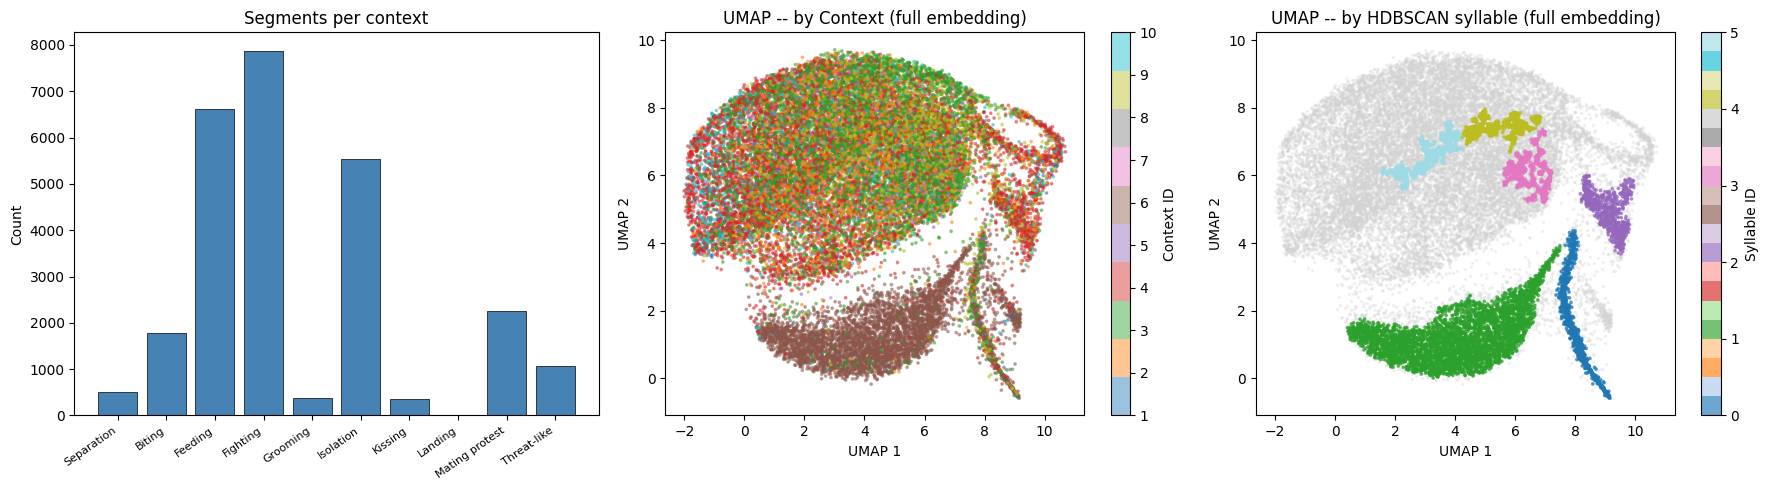

Distinct syllable IDs (incl. noise=-1): 7


In [4]:
if len(seg_df) == 0:
    print('seg_df is empty -- check WAV paths.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Context distribution
    ctx_counts = seg_df['Context'].value_counts().sort_index()
    axes[0].bar([CONTEXT_NAMES.get(c, str(c)) for c in ctx_counts.index], ctx_counts.values,
                color='steelblue', edgecolor='black', linewidth=0.5)
    axes[0].set_title('Segments per context')
    axes[0].set_ylabel('Count')
    plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=8)

    # Plot full embedding (subsample only for rendering speed)
    max_plot = 80_000
    if len(seg_df) > max_plot:
        _plot_idx = np.random.default_rng(RANDOM_STATE).choice(len(seg_df), size=max_plot, replace=False)
    else:
        _plot_idx = np.arange(len(seg_df))

    emb_plot = embedding_all[_plot_idx]
    seg_plot = seg_df.iloc[_plot_idx]
    labels_plot = seg_plot['syllable_id'].values

    # 2) UMAP colored by context
    sc1 = axes[1].scatter(
        emb_plot[:, 0], emb_plot[:, 1],
        c=seg_plot['Context'].astype(int).values,
        s=3, alpha=0.45, cmap='tab10'
    )
    axes[1].set_title('UMAP -- by Context (full embedding)')
    axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
    plt.colorbar(sc1, ax=axes[1], label='Context ID')

    # 3) UMAP colored by HDBSCAN syllable
    noise_mask = labels_plot == -1
    axes[2].scatter(emb_plot[noise_mask, 0], emb_plot[noise_mask, 1],
                    c='lightgray', s=2, alpha=0.25, label='noise')
    sc2 = axes[2].scatter(emb_plot[~noise_mask, 0], emb_plot[~noise_mask, 1],
                          c=labels_plot[~noise_mask], s=3, alpha=0.65, cmap='tab20')
    axes[2].set_title('UMAP -- by HDBSCAN syllable (full embedding)')
    axes[2].set_xlabel('UMAP 1'); axes[2].set_ylabel('UMAP 2')
    plt.colorbar(sc2, ax=axes[2], label='Syllable ID')

    plt.tight_layout()
    plt.show()

    print(f'Distinct syllable IDs (incl. noise=-1): {seg_df["syllable_id"].nunique()}')

## 4. Per-file syllable sequences

In [5]:
by_file = (
    seg_df.sort_values(['FileName', 'StartSample'])
    .groupby('FileName', sort=False)
    .agg(
        seq_clean=('syllable_id', lambda x: [v for v in x if v >= 0]),
        context=('Context', lambda x: int(x.mode().iloc[0])),
        emitter=('Emitter', 'first'),
    )
    .reset_index()
)
by_file = by_file[by_file['seq_clean'].apply(len) >= 2].copy()

# Paper filter: keep only contexts with ≥ MIN_SAMPLES_PER_CONTEXT files
ctx_counts = by_file['context'].value_counts()
keep_ctx   = ctx_counts[ctx_counts >= MIN_SAMPLES_PER_CONTEXT].index
by_file    = by_file[by_file['context'].isin(keep_ctx)].copy()
by_file    = by_file.rename(columns={'seq_clean': 'seq'})

print(f'Files with ≥2 non-noise syllables after filter: {len(by_file)}')
print(f'Contexts kept (≥{MIN_SAMPLES_PER_CONTEXT} files): {sorted(by_file["context"].unique())}')
print(by_file['context'].map(CONTEXT_NAMES).value_counts().sort_index())

Files with ≥2 non-noise syllables after filter: 0
Contexts kept (≥30 files): []
Series([], Name: count, dtype: int64)


In [6]:
if len(by_file) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    _cvc = by_file['context'].value_counts().sort_index()
    ax1.bar([CONTEXT_NAMES.get(c, str(c)) for c in _cvc.index], _cvc.values,
            color='teal', edgecolor='black', linewidth=0.5)
    ax1.set_title('Files per context (after filter)')
    ax1.set_ylabel('Files')
    plt.setp(ax1.get_xticklabels(), rotation=35, ha='right', fontsize=8)

    _lens = by_file['seq'].apply(len)
    ax2.hist(_lens, bins=40, color='coral', edgecolor='black', linewidth=0.5)
    ax2.set_title('Sequence length distribution')
    ax2.set_xlabel('Syllables per file'); ax2.set_ylabel('Files')
    plt.tight_layout(); plt.show()

## 5. Sequence features (18 features a–r)

Exact port of `prepare_data_from_sequences` from `Exp1 - Classifier.ipynb`.

In [7]:
import math
import collections
import networkx as nx
from itertools import pairwise
from scipy.stats import entropy as _scipy_entropy

# ── Helper functions ──────────────────────────────────────────────────────

def _num_syl_types(seq):
    return len(set(seq))

def _num_all_syl(seq):
    return len(seq)

def _num_trans_in_seq(seq):
    return sum(collections.Counter(pairwise(seq)).values())

def _linearity(seq):
    n_types = len(set(seq))
    n_trans = len(set(pairwise(seq)))
    return n_types / n_trans if n_trans else 0

def _consistency(seq, n_trans_ctx):
    n_t = len(set(pairwise(seq)))
    return n_t / n_trans_ctx if n_trans_ctx else 0

def _entropy_order0(seq, prob_syl):
    e = 0.0
    for s in seq:
        p = prob_syl.get(s, 1e-9)
        e -= p * math.log2(p)
    return e

def _transitions_dict(sequences):
    trans = sequences.apply(lambda x: list(pairwise(x))).explode().value_counts()
    total = trans.sum()
    return trans.apply(lambda v: v / total).to_dict() if total else {}

def _compute_trans_prob(sequences):
    G = nx.DiGraph()
    for seq in sequences:
        for a, b in pairwise(seq):
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)
    trans = {}
    for src in G.nodes():
        tot = sum(G[src][tgt]['weight'] for tgt in G.successors(src))
        trans[src] = {tgt: G[src][tgt]['weight'] / tot for tgt in G.successors(src)}
    return trans

def _cond_prob_n(sequences, n):
    from collections import defaultdict
    cond_freqs = defaultdict(lambda: defaultdict(int))
    for seq in sequences:
        ants = []
        for i in range(n):
            if i < len(seq):
                ants.append(seq[i])
        for i, item in enumerate(seq):
            cond_freqs[tuple(ants)][item] += 1
            if len(ants) >= n:
                ants.pop(0)
            ants.append(item)
    return {k: {item: f / sum(d.values()) for item, f in d.items()}
            for k, d in cond_freqs.items()}

def _num_trans_types_ctx(df, ctx_id):
    pairs = set()
    for seq in df[df['context'] == ctx_id]['seq']:
        pairs.update(pairwise(seq))
    return len(pairs)

def _prob_syl_ctx(df, ctx_id):
    seqs = df[df['context'] == ctx_id]['seq']
    freq = seqs.explode().value_counts()
    total = freq.sum()
    return freq.apply(lambda v: v / total).to_dict() if total else {}

def _cond_prob_of_seq(seq, cond_dict, init_prob):
    if not seq:
        return 0.0
    p = init_prob.get(seq[0], 1e-9)
    for i in range(1, len(seq)):
        ant = seq[i - 1]
        cur = seq[i]
        key = (ant,)
        if key in cond_dict and cur in cond_dict[key]:
            p *= cond_dict[key][cur]
    return p

def _transitions_in_ctx(seq, trans_dict):
    probs = [trans_dict.get(p, 1e-9) for p in pairwise(seq)]
    return math.prod(probs) if probs else 0.0

def _uncertainty_trans(seq, trans_probs):
    if len(seq) < 2:
        return 0.0
    h = 0.0
    for a, b in pairwise(seq):
        p = trans_probs.get(a, {}).get(b, 1e-9)
        h += p * math.log2(p)
    return -h

def _make_graph(df):
    G = nx.DiGraph()
    all_seqs = df['seq']
    total_syl = len(all_seqs.explode().unique())
    for syl, freq in all_seqs.explode().value_counts().items():
        G.add_node(syl, frequency=freq, p_frequency=freq / total_syl)
    all_edges = [p for seq in all_seqs for p in pairwise(seq)]
    total_edges = len(all_edges)
    for (a, b), cnt in collections.Counter(all_edges).items():
        posteriors = [e for e in all_edges if e[0] == a]
        antecedents = [e for e in all_edges if e[1] == b]
        p_trans = cnt / len(posteriors) if posteriors else 1e-9
        p_cond  = cnt / len(antecedents) if antecedents else 1e-9
        G.add_edge(a, b,
                   frequency=cnt,
                   p_frequency=cnt / total_edges,
                   p_trans=p_trans,
                   p_cond=p_cond)
    return G

# ── Pre-compute per-context statistics ────────────────────────────────────
print('Building context statistics and graph...')
contexts = sorted(by_file['context'].unique())

_trans_in_ctx   = {c: _num_trans_types_ctx(by_file, c) for c in contexts}
_prob_syl_ctx   = {c: _prob_syl_ctx(by_file, c) for c in contexts}
_cond_prob_ctx  = {c: _cond_prob_n(by_file[by_file['context']==c]['seq'], 1) for c in contexts}
_trans_probs_ctx = {c: _compute_trans_prob(by_file[by_file['context']==c]['seq']) for c in contexts}
_trans_dict_ctx  = {c: _transitions_dict(by_file[by_file['context']==c]['seq']) for c in contexts}

_cond_prob_all   = _cond_prob_n(by_file['seq'], 1)
_cond_prob_all2  = _cond_prob_n(by_file['seq'], 2)
_trans_dict_all  = _transitions_dict(by_file['seq'])
_trans_probs_all = _compute_trans_prob(by_file['seq'])
_all_pairs       = by_file['seq'].apply(lambda x: list(pairwise(x))).explode().value_counts()
_trans_in_total  = int(_all_pairs.sum()) if len(_all_pairs) else 1
_freq_syl_all    = by_file['seq'].explode().value_counts()
_prob_syl_all    = (_freq_syl_all / _freq_syl_all.sum()).to_dict()

G = _make_graph(by_file)
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print('Context statistics done.')

Building context statistics and graph...
Graph: 0 nodes, 0 edges
Context statistics done.


In [8]:
def extract_features(data_df):
    cols = list(map(chr, range(97, 97 + 18)))   # a..r
    d = {c: [] for c in cols}

    for _, row in data_df.iterrows():
        seq  = row['seq']
        ctx  = row['context']
        init = _prob_syl_ctx.get(ctx, _prob_syl_all)

        d['a'].append(_num_syl_types(seq))
        d['b'].append(_num_all_syl(seq))
        d['c'].append(_num_trans_in_seq(seq))
        d['d'].append(_linearity(seq))
        d['e'].append(_consistency(seq, _trans_in_ctx.get(ctx, _trans_in_total)))
        d['f'].append(_entropy_order0(seq, _prob_syl_ctx.get(ctx, _prob_syl_all)))
        d['g'].append(_cond_prob_of_seq(seq, _cond_prob_ctx.get(ctx, _cond_prob_all), init))
        d['h'].append(_transitions_in_ctx(seq, _trans_dict_ctx.get(ctx, _trans_dict_all)))
        d['i'].append(_num_syl_types(seq) / max(_num_all_syl(seq), 1))   # versatility
        d['j'].append(_uncertainty_trans(seq, _trans_probs_ctx.get(ctx, _trans_probs_all)))

        # k–m: graph-based transition products
        probs_k, probs_lm = [], []
        for p in pairwise(seq):
            if p in G.edges:
                probs_k.append(G.edges[p].get('p_trans', 1e-9))
                probs_lm.append((G.edges[p].get('p_cond', 1e-9),
                                 G.edges[p].get('p_trans', 1e-9)))
        d['k'].append(math.prod(probs_k) if probs_k else 0.0)
        d['l'].append(math.prod(c * math.log2(c) for c, _ in probs_lm) if probs_lm else 0.0)
        d['m'].append(math.prod(t * math.log2(t) for _, t in probs_lm) if probs_lm else 0.0)

        # n: 1-gram conditional product
        pc = [init.get(seq[0], 1e-9)]
        for i in range(1, len(seq)):
            ant, cur = seq[i-1], seq[i]
            pc.append(_cond_prob_all.get((ant,), {}).get(cur, 1e-9))
        d['n'].append(math.prod(pc))

        # o, p: graph-based node/edge products
        po, pp = [G.nodes[seq[0]].get('p_frequency', 1e-9)] if seq[0] in G else [1e-9], []
        for i in range(1, len(seq)):
            a, b = seq[i-1], seq[i]
            if a in G and b in G[a]:
                po.append(G[a][b].get('p_cond', 1e-9))
                if i < len(seq) - 1:
                    c_ = seq[i+1]
                    if b in G and c_ in G[b]:
                        pp.append(G[b][c_].get('p_trans', 1e-9))
        d['o'].append(math.prod(po))
        d['p'].append(math.prod(pp) if pp else 0.0)

        # q: 2-gram conditional product
        pq = [init.get(seq[0], 1e-9)]
        for i in range(1, len(seq)):
            ant = seq[i-1]
            cur = seq[i]
            v = _cond_prob_all.get((ant,), {}).get(cur, 1e-9)
            if i > 1:
                ant2 = seq[i-2]
                v2 = _cond_prob_all2.get((ant2, ant), {}).get(cur, 1e-9)
                v = v * v2
            pq.append(v)
        d['q'].append(math.prod(pq))

        # r: perplexity
        d['r'].append(math.prod(1/p for p in pq) ** (1/len(pq)) if pq else 0.0)

    return pd.DataFrame(d)


print('Extracting features...')
feat = extract_features(by_file).fillna(0).replace([np.inf, -np.inf], 0)
y    = by_file['context'].values
print(f'Feature matrix: {feat.shape} | classes: {np.unique(y)}')

Extracting features...
Feature matrix: (0, 18) | classes: []


## 6. SVM classifier (HP1 — original sequences)

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

if feat.shape[0] < 10:
    print('Too few samples for classification. Skipping.')
else:
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_tr, X_te, y_tr, y_te = train_test_split(feat, y_enc, test_size=0.2,
                                                stratify=y_enc, random_state=RANDOM_STATE)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s  = sc.transform(X_te)

    param_grid = {'C': np.logspace(-3, 3, 7), 'gamma': np.logspace(-3, 3, 7), 'kernel': ['rbf']}
    cv = StratifiedKFold(n_splits=min(10, int(np.bincount(y_tr).min())), shuffle=True,
                         random_state=RANDOM_STATE)
    grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_tr_s, y_tr)

    y_pred = grid.best_estimator_.predict(X_te_s)
    print('=== SVM (original sequences) ===')
    print(f'Best params: {grid.best_params_}')
    print(f'F1-micro : {f1_score(y_te, y_pred, average="micro"):.3f}')
    print(f'F1-macro : {f1_score(y_te, y_pred, average="macro"):.3f}')
    print(f'F1-weighted: {f1_score(y_te, y_pred, average="weighted"):.3f}')
    print()
    print(classification_report(y_te, y_pred, target_names=le.classes_.astype(str)))

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=[CONTEXT_NAMES.get(c, str(c)) for c in le.classes_],
        ax=ax, colorbar=False, xticks_rotation='vertical'
    )
    ax.set_title('SVM — original sequences')
    plt.tight_layout(); plt.show()

Too few samples for classification. Skipping.


## 7. HP1 — Permutation test: associative vs combinatorial syntax

HP1₀: syllable *order* does not affect context classification.
→ Shuffle syllable order within each file, extract features, run same SVM.
→ If F1 stays ≈ same → **associative syntax** (meaning from presence, not order).

In [10]:
if feat.shape[0] < 10:
    print('Too few samples. Skipping.')
else:
    np.random.seed(RANDOM_STATE)
    by_file_perm = by_file.copy()
    by_file_perm['seq'] = by_file_perm['seq'].apply(
        lambda s: list(np.random.permutation(s)))

    feat_perm = extract_features(by_file_perm).fillna(0).replace([np.inf, -np.inf], 0)
    y_perm    = by_file_perm['context'].values
    y_perm_enc = le.transform(y_perm)

    X_perm_s = sc.transform(feat_perm)
    y_pred_perm = grid.best_estimator_.predict(X_perm_s)

    f1_orig = f1_score(y_te, y_pred, average='weighted')
    f1_perm = f1_score(y_perm_enc, y_pred_perm, average='weighted')

    print('=== HP1: Permutation test ===')
    print(f'F1-weighted original  : {f1_orig:.3f}')
    print(f'F1-weighted permuted  : {f1_perm:.3f}')
    delta = abs(f1_orig - f1_perm)
    print(f'|Δ F1|                : {delta:.3f}')
    if delta < 0.05:
        print('→ Order does NOT significantly affect F1 → ASSOCIATIVE SYNTAX (HP1₀ not rejected)')
    else:
        print('→ Order DOES affect F1 → COMBINATORIAL SYNTAX component (HP1₀ rejected)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=[CONTEXT_NAMES.get(c, str(c)) for c in le.classes_],
        ax=axes[0], colorbar=False, xticks_rotation='vertical')
    axes[0].set_title(f'Original  F1-w={f1_orig:.2f}')

    ConfusionMatrixDisplay.from_predictions(
        y_perm_enc, y_pred_perm,
        display_labels=[CONTEXT_NAMES.get(c, str(c)) for c in le.classes_],
        ax=axes[1], colorbar=False, xticks_rotation='vertical')
    axes[1].set_title(f'Permuted  F1-w={f1_perm:.2f}')
    plt.tight_layout(); plt.show()

Too few samples. Skipping.


## 8. Random Forest comparison (Exp1 cell 168)

In [11]:
from sklearn.ensemble import RandomForestClassifier

if feat.shape[0] < 10:
    print('Too few samples. Skipping.')
else:
    rf = RandomForestClassifier(criterion='entropy', n_estimators=100,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr_s, y_tr)
    y_pred_rf     = rf.predict(X_te_s)
    y_pred_rf_perm = rf.predict(X_perm_s)

    print('=== Random Forest ===')
    print(f'Original  — F1-micro: {f1_score(y_te, y_pred_rf, average="micro"):.3f} '
          f'F1-weighted: {f1_score(y_te, y_pred_rf, average="weighted"):.3f}')
    print(f'Permuted  — F1-micro: {f1_score(y_perm_enc, y_pred_rf_perm, average="micro"):.3f} '
          f'F1-weighted: {f1_score(y_perm_enc, y_pred_rf_perm, average="weighted"):.3f}')

Too few samples. Skipping.


## 9. HP2 — Wilcoxon rank-sum: syllable usage across contexts

HP2₀: syllable distributions are identical across behavioral contexts.

In [12]:
from scipy.stats import ranksums
import itertools

if len(by_file) == 0:
    print('No data.')
else:
    # syllable frequency vector per file
    all_syls = sorted(seg_df[seg_df['syllable_id'] >= 0]['syllable_id'].unique())
    syl_freq = {}
    for ctx in contexts:
        seqs = by_file[by_file['context'] == ctx]['seq']
        counts = seqs.explode().value_counts().reindex(all_syls, fill_value=0)
        total  = counts.sum() or 1
        syl_freq[ctx] = counts / total

    syl_freq_df = pd.DataFrame(syl_freq)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(syl_freq_df, ax=ax, cmap='YlOrRd', linewidths=0.3)
    ax.set_xticklabels([CONTEXT_NAMES.get(c, str(c)) for c in syl_freq_df.columns],
                       rotation=35, ha='right', fontsize=8)
    ax.set_title('Syllable frequency heatmap by context')
    plt.tight_layout(); plt.show()

    print('\nPairwise Wilcoxon rank-sum tests (p < 0.05 → reject HP2₀):')
    pairs = list(itertools.combinations(contexts, 2))
    sig_pairs = []
    for c1, c2 in pairs:
        seqs1 = by_file[by_file['context']==c1]['seq'].explode().value_counts().reindex(all_syls, fill_value=0)
        seqs2 = by_file[by_file['context']==c2]['seq'].explode().value_counts().reindex(all_syls, fill_value=0)
        stat, p = ranksums(seqs1, seqs2)
        marker = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        n1, n2 = CONTEXT_NAMES.get(c1, str(c1)), CONTEXT_NAMES.get(c2, str(c2))
        if p < 0.05:
            sig_pairs.append((n1, n2, p))
        print(f'  {n1:20s} vs {n2:20s}  p={p:.4f} {marker}')
    print(f'\nSignificant pairs: {len(sig_pairs)}/{len(pairs)}')

No data.


## 10. HP3 — Maximal Repeats: exponential vs power-law

HP3₀: the distribution of maximal repetition lengths follows an exponential distribution.
→ Power-law (truncated) → long-range dependencies → combinatorial capacity.

In [13]:
try:
    from suffix_tree import Tree as SuffixTree
    _has_suffix_tree = True
except ImportError:
    print('suffix_tree not installed. Run: pip install suffix_tree')
    _has_suffix_tree = False

if _has_suffix_tree and len(by_file) > 0:
    print('Building suffix tree for all sequences...')
    tree_input = {i: seq for i, seq in enumerate(by_file['seq'].tolist())}
    _stree = SuffixTree(tree_input)

    mr_lengths = []
    for _C, _path in _stree.maximal_repeats():
        path_list = str(_path).split()
        if len(path_list) >= 2:
            try:
                ints = [int(x) for x in path_list if int(x) >= 0]
                if len(ints) >= 2:
                    mr_lengths.append(len(ints))
            except (ValueError, TypeError):
                pass

    mr_lengths = pd.Series(mr_lengths)
    print(f'Maximal repeats found: {len(mr_lengths):,}')
    print(mr_lengths.describe())

    # Histogram
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(mr_lengths, bins=40, color='purple', edgecolor='black', linewidth=0.4, alpha=0.8)
    ax.set_title('Maximal Repeat lengths (all contexts)')
    ax.set_xlabel('MR length'); ax.set_ylabel('Count')
    plt.tight_layout(); plt.show()
else:
    print('Skipping MR analysis.')

Skipping MR analysis.


In [14]:
# Power-law vs exponential fit
try:
    import powerlaw
    _has_powerlaw = True
except ImportError:
    print('powerlaw not installed. Run: pip install powerlaw')
    _has_powerlaw = False

if _has_suffix_tree and _has_powerlaw and len(mr_lengths) > 20:
    _data = mr_lengths[mr_lengths > 1].tolist()
    fit = powerlaw.Fit(_data, discrete=True, verbose=False)
    R, p = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
    print(f'Power-law fit: alpha={fit.alpha:.3f}, sigma={fit.sigma:.3f}, xmin={fit.xmin}')
    print(f'LR test (power_law vs exponential): R={R:.3f}, p={p:.4f}')
    if p < 0.05 and R > 0:
        print('→ Power-law better fit → REJECT HP3₀ (heavy-tailed, long-range dependencies)')
    else:
        print('→ Cannot reject HP3₀ at p<0.05')

    fig, ax = plt.subplots(figsize=(7, 4))
    fit.plot_pdf(ax=ax, color='purple', label='Empirical PDF')
    fit.power_law.plot_pdf(ax=ax, color='red', linestyle='--', label=f'Power law α={fit.alpha:.2f}')
    fit.exponential.plot_pdf(ax=ax, color='green', linestyle=':', label='Exponential')
    ax.set_title('MR length distribution: power-law vs exponential')
    ax.set_xlabel('MR length'); ax.set_ylabel('P(X)')
    ax.legend(); plt.tight_layout(); plt.show()
elif _has_suffix_tree:
    print('Not enough MR data for power-law fitting.')

NameError: name 'mr_lengths' is not defined

### MR length per context (conflict vs cooperative)

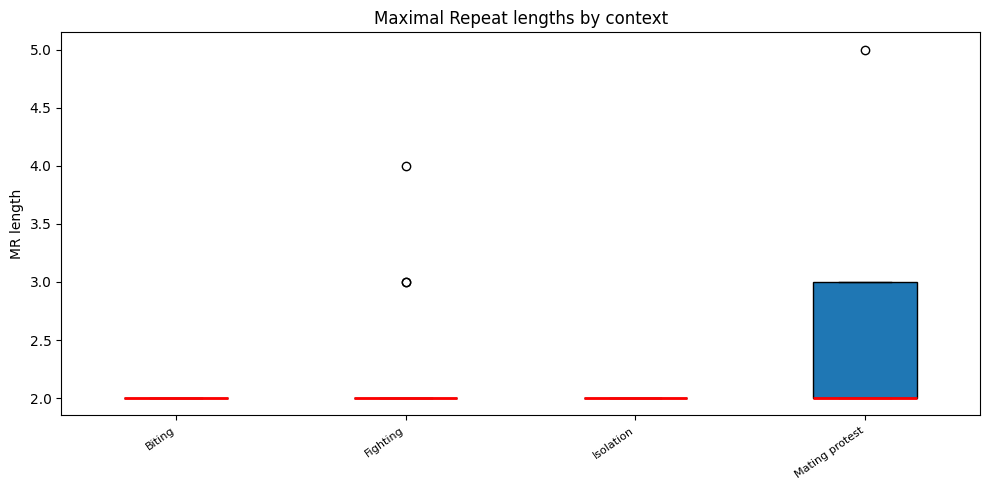

Mean MR length per context:
  Biting              : mean=2.00 median=2 n=3
  Fighting            : mean=2.27 median=2 n=15
  Isolation           : mean=2.00 median=2 n=5
  Mating protest      : mean=2.50 median=2 n=12


In [ ]:
if _has_suffix_tree and len(by_file) > 0:
    mr_by_ctx = {}
    for ctx in contexts:
        _seqs = {i: seq for i, seq in enumerate(by_file[by_file['context']==ctx]['seq'].tolist())}
        if not _seqs:
            continue
        _tree = SuffixTree(_seqs)
        _lens = []
        for _C, _path in _tree.maximal_repeats():
            _pl = str(_path).split()
            try:
                _ints = [int(x) for x in _pl if int(x) >= 0]
                if len(_ints) >= 2:
                    _lens.append(len(_ints))
            except (ValueError, TypeError):
                pass
        mr_by_ctx[ctx] = pd.Series(_lens)

    if mr_by_ctx:
        fig, ax = plt.subplots(figsize=(10, 5))
        data_plot = [mr_by_ctx[c].tolist() for c in contexts if c in mr_by_ctx and len(mr_by_ctx[c]) > 0]
        labels_plot = [CONTEXT_NAMES.get(c, str(c)) for c in contexts if c in mr_by_ctx and len(mr_by_ctx[c]) > 0]
        ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                   medianprops={'color': 'red', 'linewidth': 2})
        plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
        ax.set_title('Maximal Repeat lengths by context')
        ax.set_ylabel('MR length')
        plt.tight_layout(); plt.show()

        print('Mean MR length per context:')
        for ctx in contexts:
            if ctx in mr_by_ctx and len(mr_by_ctx[ctx]) > 0:
                print(f'  {CONTEXT_NAMES.get(ctx, str(ctx)):20s}: mean={mr_by_ctx[ctx].mean():.2f} '
                      f'median={mr_by_ctx[ctx].median():.0f} n={len(mr_by_ctx[ctx])}')

## 11. Syllabic transition networks per context

Small-world metrics: clustering coefficient (Avg C), small-world index ω, network density.

In [ ]:
def _build_ctx_graph(df, ctx_id):
    seqs = df[df['context'] == ctx_id]['seq']
    G_ctx = nx.DiGraph()
    for seq in seqs:
        for a, b in pairwise(seq):
            if G_ctx.has_edge(a, b):
                G_ctx[a][b]['weight'] += 1
            else:
                G_ctx.add_edge(a, b, weight=1)
    return G_ctx

def _small_world_omega(G):
    try:
        Gu = G.to_undirected()
        if Gu.number_of_nodes() < 4 or Gu.number_of_edges() < 2:
            return np.nan, np.nan
        avg_c = nx.average_clustering(Gu)
        # omega approximation: compare to random and lattice
        rand_c = nx.average_clustering(nx.erdos_renyi_graph(
            Gu.number_of_nodes(), nx.density(Gu), seed=RANDOM_STATE))
        omega = rand_c / avg_c if avg_c > 0 else np.nan
        return avg_c, omega
    except Exception:
        return np.nan, np.nan

print('Transition network metrics per context:')
print(f'{"Context":20s} {"Nodes":>6} {"Edges":>6} {"Density":>8} {"Avg C":>7} {"ω-approx":>9}')
print('-' * 65)
for ctx in contexts:
    G_ctx = _build_ctx_graph(by_file, ctx)
    n, e  = G_ctx.number_of_nodes(), G_ctx.number_of_edges()
    dens  = nx.density(G_ctx)
    avg_c, omega = _small_world_omega(G_ctx)
    name = CONTEXT_NAMES.get(ctx, str(ctx))
    print(f'{name:20s} {n:6d} {e:6d} {dens:8.3f} '
          f'{(avg_c if not np.isnan(avg_c) else float("nan")):7.3f} '
          f'{(omega if not np.isnan(omega) else float("nan")):9.3f}')

Transition network metrics per context:
Context               Nodes  Edges  Density   Avg C  ω-approx
-----------------------------------------------------------------
Biting                    5      7    0.350   0.333     2.600
Fighting                  6     17    0.567   0.833     1.120
Isolation                 6     12    0.400   0.606     1.202
Mating protest            6     10    0.333   0.633     0.833


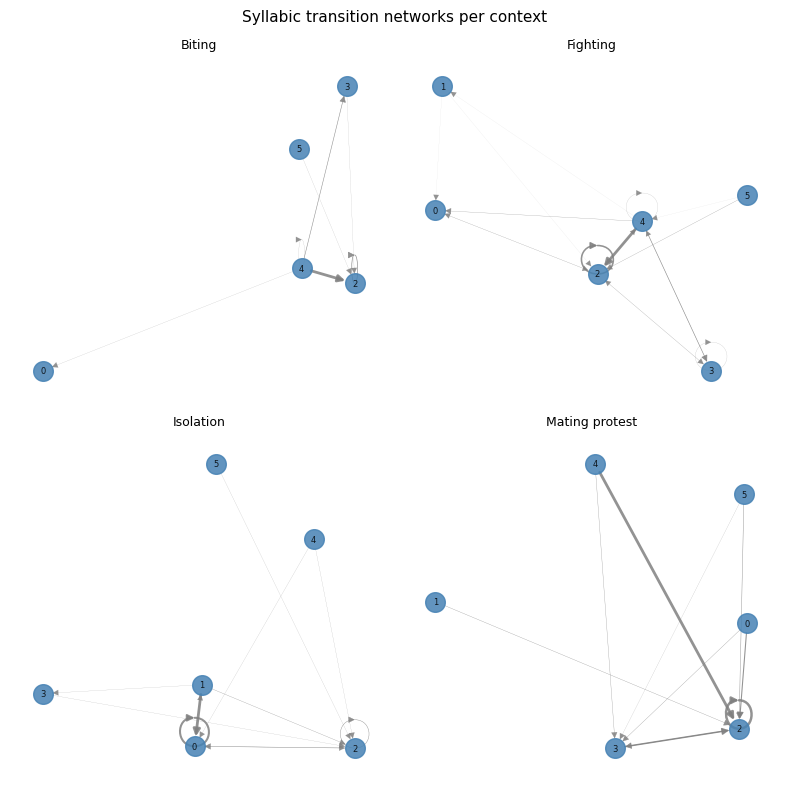

In [ ]:
# Visualize transition graphs side by side
n_ctx = len(contexts)
fig, axes = plt.subplots(2, (n_ctx + 1) // 2, figsize=(4 * ((n_ctx + 1) // 2), 8))
axes = axes.ravel()
for ax_i, ctx in enumerate(contexts):
    G_ctx = _build_ctx_graph(by_file, ctx)
    ax = axes[ax_i]
    if G_ctx.number_of_nodes() == 0:
        ax.set_visible(False); continue
    pos = nx.spring_layout(G_ctx, seed=RANDOM_STATE)
    weights = [G_ctx[u][v]['weight'] for u, v in G_ctx.edges()]
    max_w   = max(weights) if weights else 1
    nx.draw_networkx(G_ctx, pos, ax=ax,
                     node_size=200, node_color='steelblue',
                     font_size=6, arrows=True,
                     width=[2 * w / max_w for w in weights],
                     edge_color='gray', alpha=0.85)
    ax.set_title(CONTEXT_NAMES.get(ctx, str(ctx)), fontsize=9)
    ax.axis('off')
for ax_i in range(len(contexts), len(axes)):
    axes[ax_i].set_visible(False)
plt.suptitle('Syllabic transition networks per context', fontsize=11)
plt.tight_layout(); plt.show()

---
## Summary

| Step | Result |
|------|--------|
| **UMAP + HDBSCAN** | Syllable repertoire (see embedding plot) |
| **SVM classifier** | F1-weighted on original sequences |
| **HP1 permutation** | Associative vs combinatorial syntax |
| **HP2 Wilcoxon** | Context-dependent syllable usage |
| **HP3 power-law** | Heavy-tailed MR distribution (long-range dependencies) |
| **Networks** | Small-world in conflict contexts; random in cooperative |